<a href="https://www.kaggle.com/code/omborse771924/house-price-predecition-eda?scriptVersionId=328678914" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/raviiyadavv/house-price-predecition/dataset_2.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/raviiyadavv/house-price-predecition/dataset_2.csv')

In [3]:
df.head()

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0


In [4]:
df.tail()

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
1119,2461.048417,7.0,1988,Noida,Corner Plot,Unfurnished,Duplex,No,699925.0
1120,3558.174078,7.0,1989,Kanpur,Highway Facing,Unfurnished,Apartment,No,736329.0
1121,2179.880978,4.0,2011,Prayagraj,Residential Lane,Semi-Furnished,Duplex,No,533498.0
1122,NaN,6.0,2022,Delhi,Main Road,Unfurnished,Independent House,No,533436.0
1123,3022.318426,4.0,2011,Gurugram,Residential Lane,Unfurnished,Independent House,Yes,780760.0


In [5]:
df.describe()

,Area_SqFt,Rooms,Build_Year,Price
count,1091.000000,1091.000000,1124.000000,1.124000e+03
mean,2237.479473,4.568286,2005.080071,6.082015e+05
std,731.097828,1.678155,11.708876,1.431958e+05
min,700.000000,2.000000,1985.000000,2.486400e+05
25%,1834.022964,3.000000,1995.000000,5.161948e+05
50%,2201.545784,5.000000,2005.000000,6.025410e+05
75%,2576.139355,6.000000,2015.000000,6.895785e+05
max,10267.124330,7.000000,2024.000000,2.071402e+06


In [6]:
df.isnull().sum()

Area_SqFt        33
Rooms            33
Build_Year        0
Location          0
Street_Type       0
Furnishing       33
Property_Type     0
Has_Pool          0
Price             0
dtype: int64

In [7]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1119    False
1120    False
1121    False
1122    False
1123    False
Length: 1124, dtype: bool

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['Area_SqFt', 'Rooms', 'Build_Year', 'Location', 'Street_Type',
       'Furnishing', 'Property_Type', 'Has_Pool', 'Price'],
      dtype='object')

## EDA

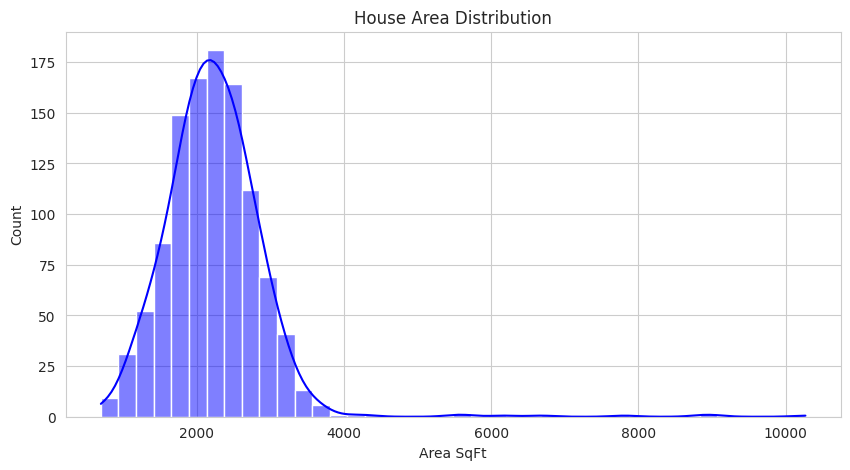

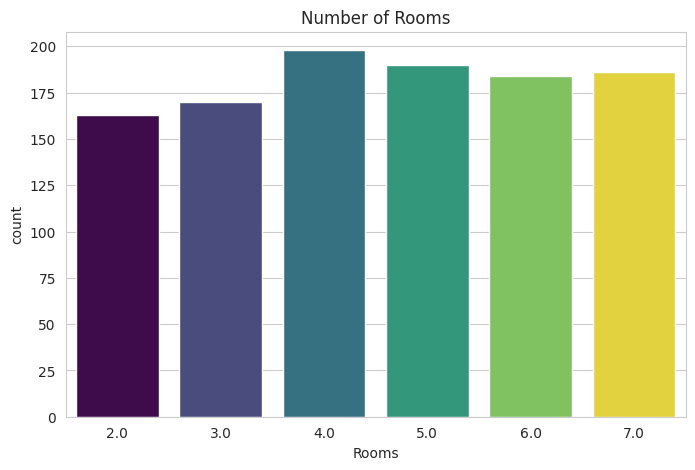

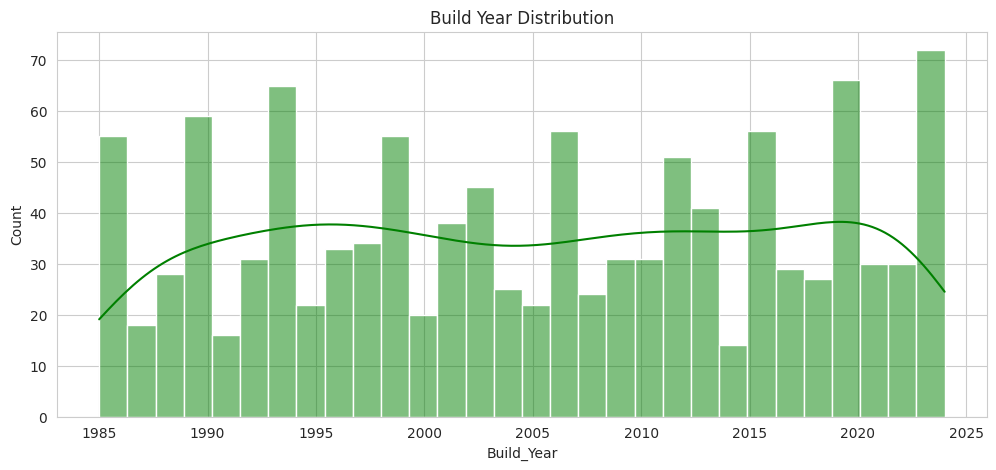

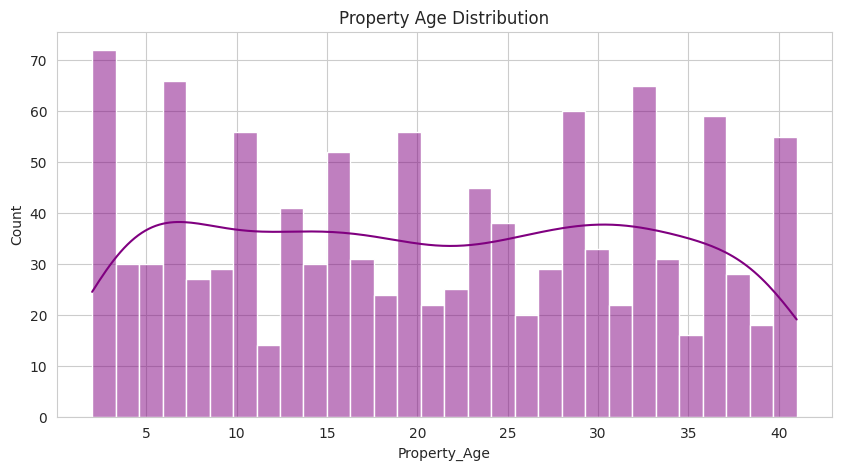

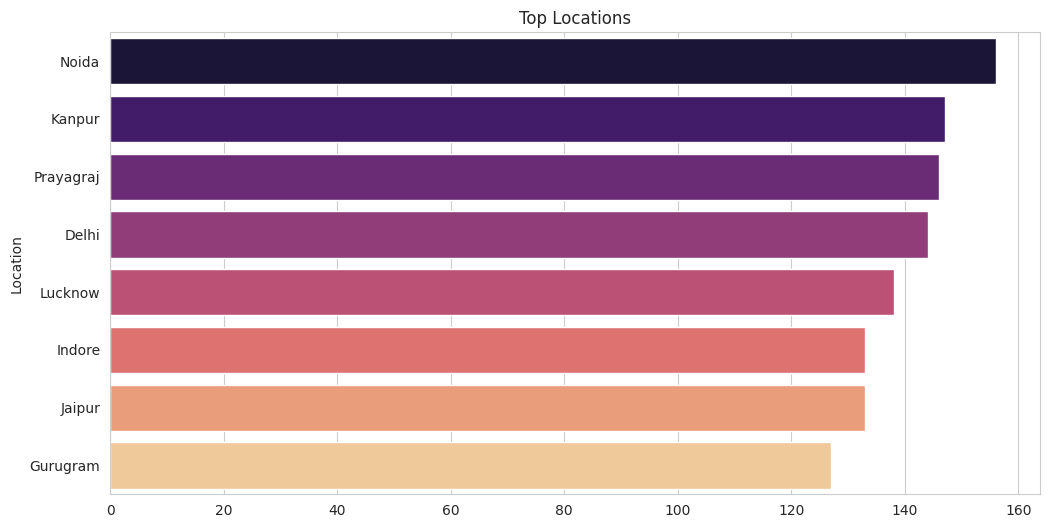

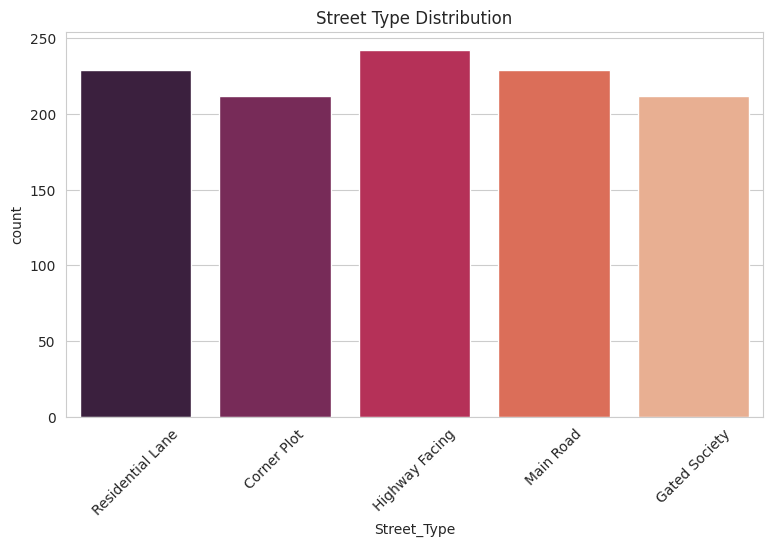

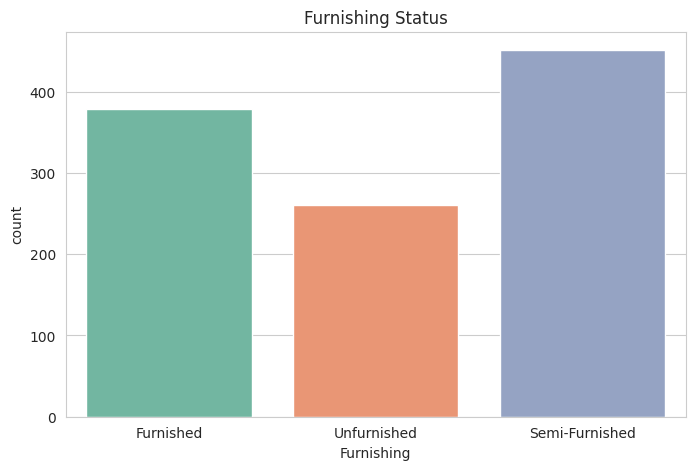

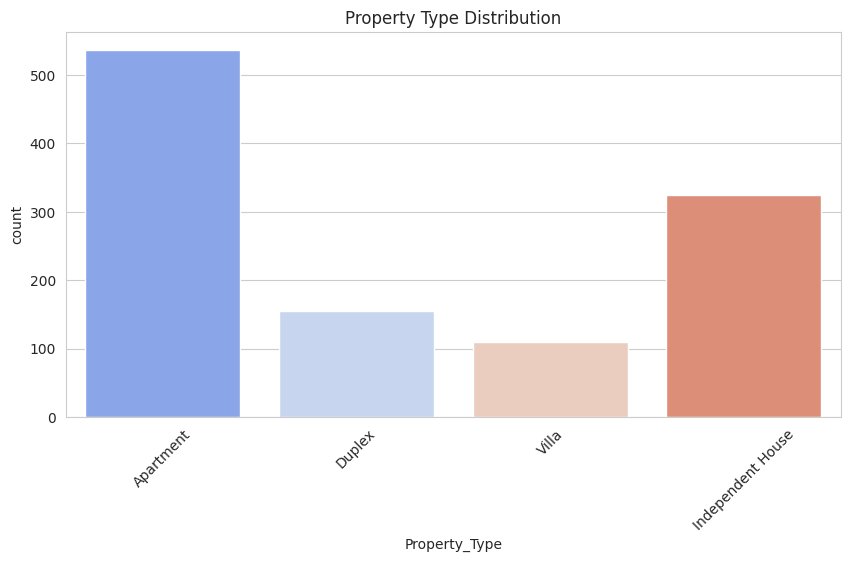

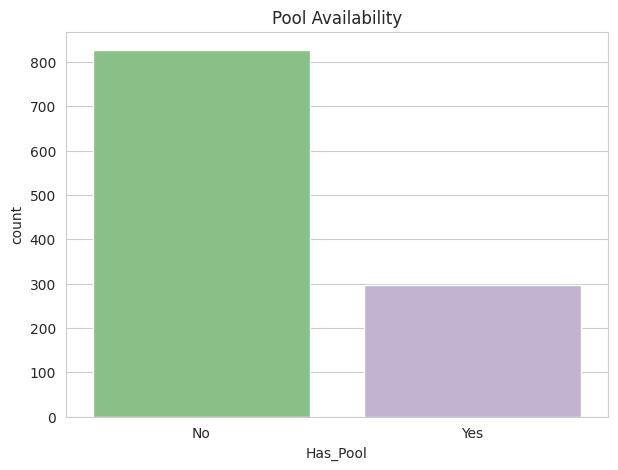

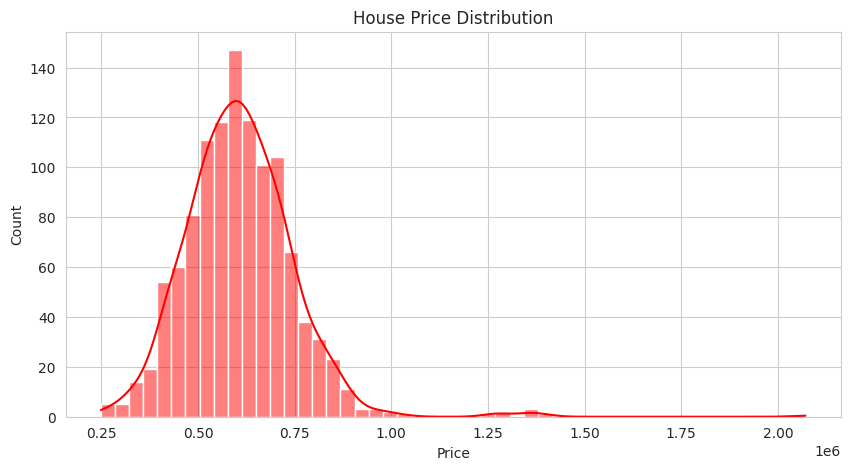

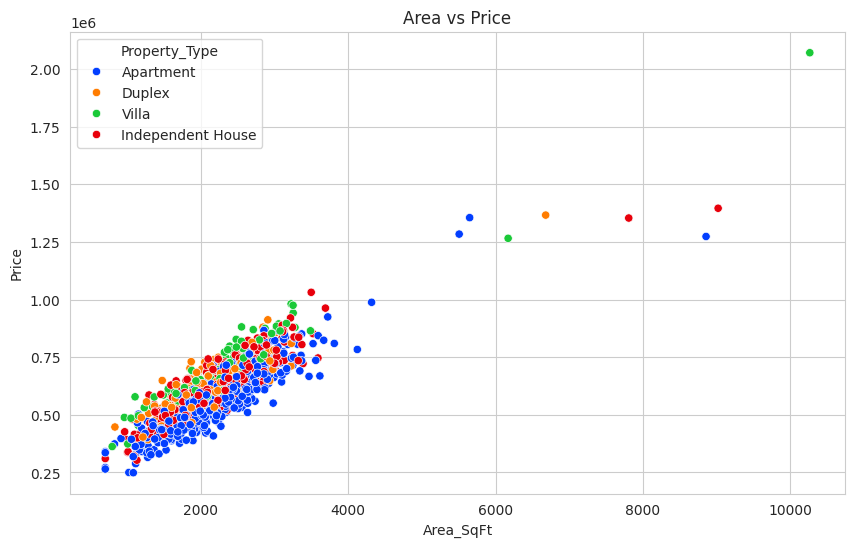

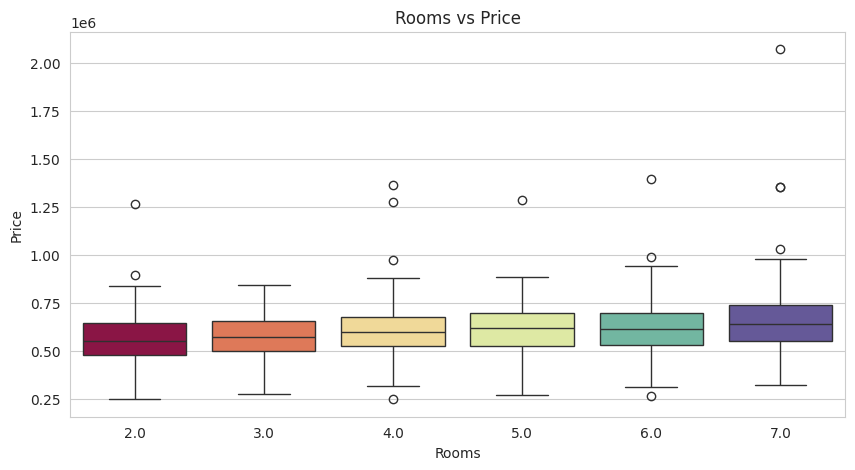

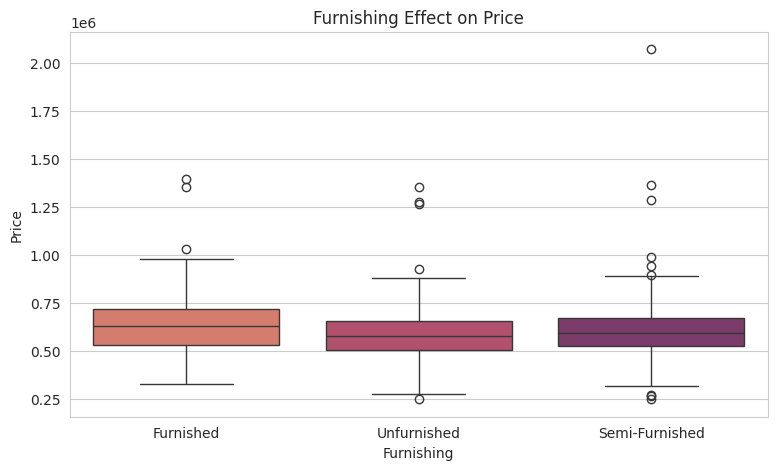

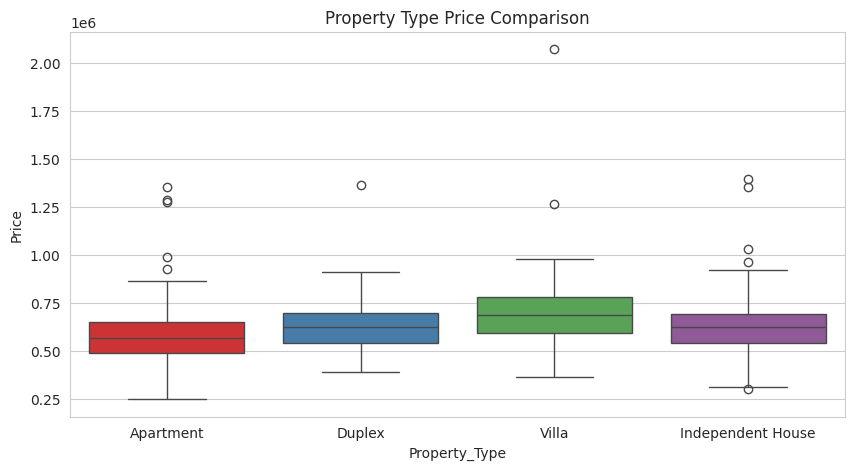

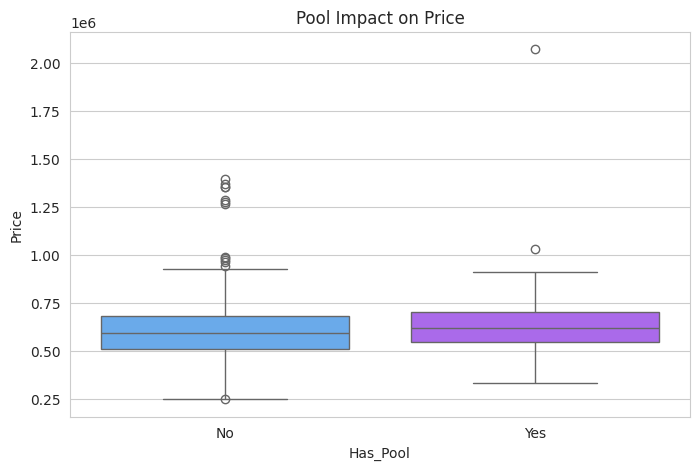

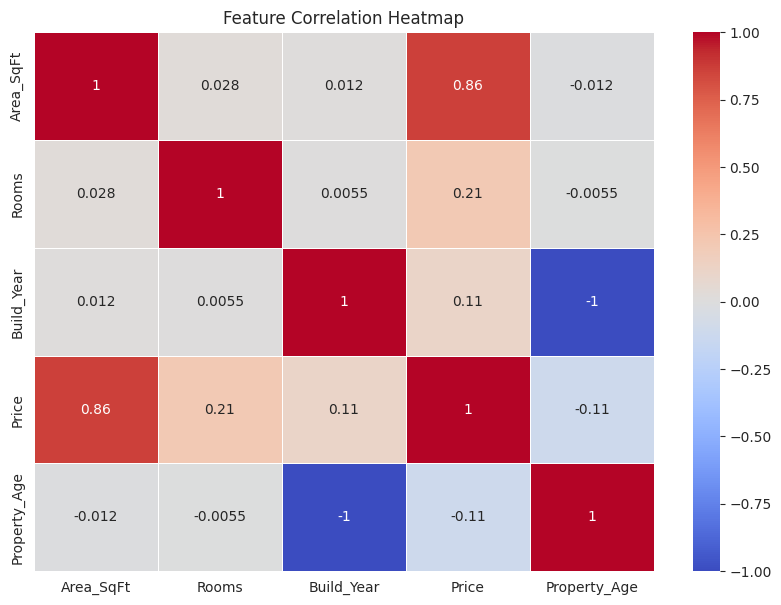

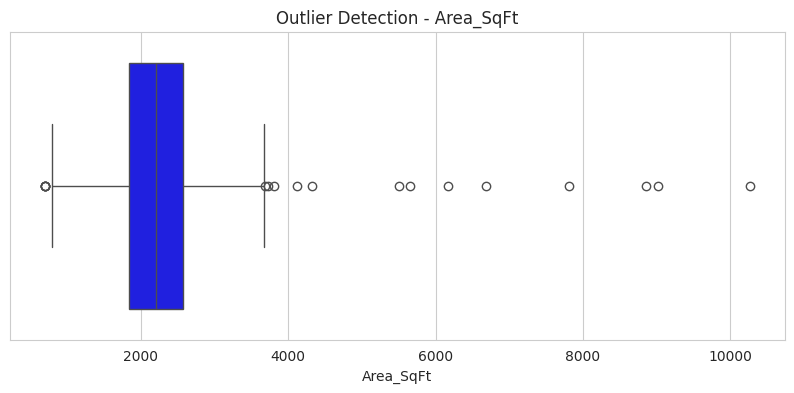

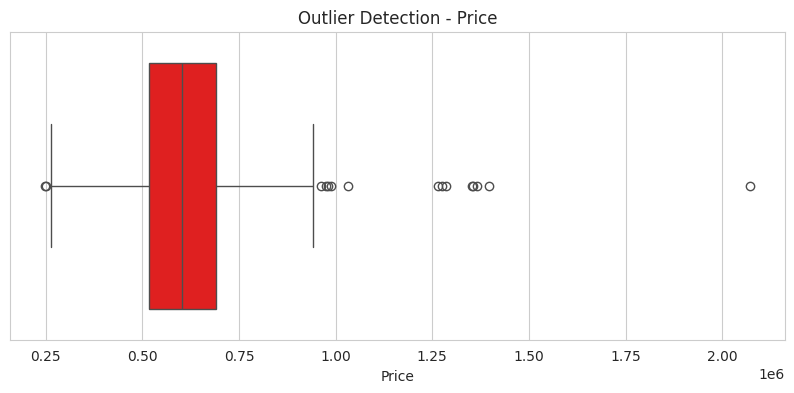

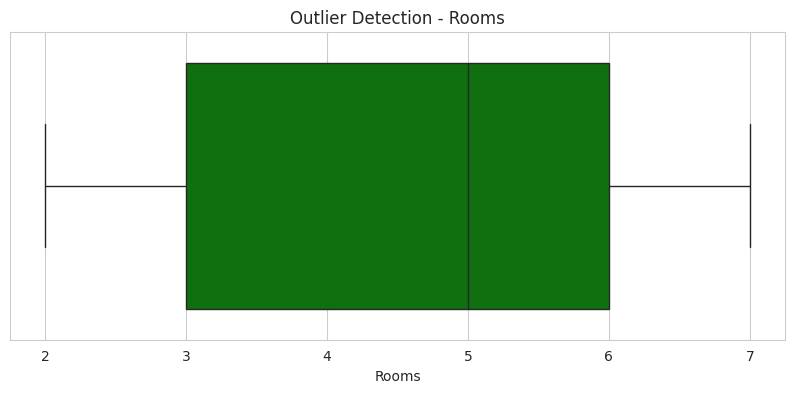

House Price Visualization Completed Successfully!


In [10]:
sns.set_style("whitegrid")

# ============================================================
# 1. AREA DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["Area_SqFt"],

    bins=40,

    kde=True,

    color="blue"

)


plt.title(
    "House Area Distribution"
)


plt.xlabel(
    "Area SqFt"
)


plt.show()







# ============================================================
# 2. ROOMS DISTRIBUTION
# ============================================================


plt.figure(figsize=(8,5))


sns.countplot(

    data=df,

    x="Rooms",

    hue="Rooms",

    palette="viridis",

    legend=False

)


plt.title(
    "Number of Rooms"
)


plt.show()








# ============================================================
# 3. BUILD YEAR ANALYSIS
# ============================================================


plt.figure(figsize=(12,5))


sns.histplot(

    df["Build_Year"],

    bins=30,

    kde=True,

    color="green"

)


plt.title(
    "Build Year Distribution"
)


plt.show()







# ============================================================
# 4. PROPERTY AGE
# ============================================================


df["Property_Age"]=2026-df["Build_Year"]



plt.figure(figsize=(10,5))


sns.histplot(

    df["Property_Age"],

    bins=30,

    kde=True,

    color="purple"

)


plt.title(
    "Property Age Distribution"
)


plt.show()








# ============================================================
# 5. LOCATION ANALYSIS
# ============================================================


location=df["Location"].value_counts().head(15)



plt.figure(figsize=(12,6))


sns.barplot(

    x=location.values,

    y=location.index,

    hue=location.index,

    palette="magma",

    legend=False

)


plt.title(
    "Top Locations"
)


plt.show()








# ============================================================
# 6. STREET TYPE
# ============================================================


plt.figure(figsize=(9,5))


sns.countplot(

    data=df,

    x="Street_Type",

    hue="Street_Type",

    palette="rocket",

    legend=False

)


plt.title(
    "Street Type Distribution"
)


plt.xticks(rotation=45)


plt.show()









# ============================================================
# 7. FURNISHING
# ============================================================


plt.figure(figsize=(8,5))


sns.countplot(

    data=df,

    x="Furnishing",

    hue="Furnishing",

    palette="Set2",

    legend=False

)


plt.title(
    "Furnishing Status"
)


plt.show()









# ============================================================
# 8. PROPERTY TYPE
# ============================================================


plt.figure(figsize=(10,5))


sns.countplot(

    data=df,

    x="Property_Type",

    hue="Property_Type",

    palette="coolwarm",

    legend=False

)



plt.title(
    "Property Type Distribution"
)


plt.xticks(rotation=45)


plt.show()








# ============================================================
# 9. HAS POOL
# ============================================================


plt.figure(figsize=(7,5))


sns.countplot(

    data=df,

    x="Has_Pool",

    hue="Has_Pool",

    palette="Accent",

    legend=False

)


plt.title(
    "Pool Availability"
)


plt.show()








# ============================================================
# 10. PRICE DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["Price"],

    bins=50,

    kde=True,

    color="red"

)


plt.title(
    "House Price Distribution"
)


plt.show()







# ============================================================
# 11. AREA VS PRICE
# ============================================================


plt.figure(figsize=(10,6))


sns.scatterplot(

    data=df,

    x="Area_SqFt",

    y="Price",

    hue="Property_Type",

    palette="bright"

)



plt.title(
    "Area vs Price"
)


plt.show()








# ============================================================
# 12. ROOMS VS PRICE
# ============================================================


plt.figure(figsize=(10,5))


sns.boxplot(

    data=df,

    x="Rooms",

    y="Price",

    hue="Rooms",

    palette="Spectral",

    legend=False

)


plt.title(
    "Rooms vs Price"
)


plt.show()







# ============================================================
# 13. FURNISHING VS PRICE
# ============================================================


plt.figure(figsize=(9,5))


sns.boxplot(

    data=df,

    x="Furnishing",

    y="Price",

    hue="Furnishing",

    palette="flare",

    legend=False

)


plt.title(
    "Furnishing Effect on Price"
)


plt.show()








# ============================================================
# 14. PROPERTY TYPE VS PRICE
# ============================================================


plt.figure(figsize=(10,5))


sns.boxplot(

    data=df,

    x="Property_Type",

    y="Price",

    hue="Property_Type",

    palette="Set1",

    legend=False

)


plt.title(
    "Property Type Price Comparison"
)


plt.show()








# ============================================================
# 15. POOL VS PRICE
# ============================================================


plt.figure(figsize=(8,5))


sns.boxplot(

    data=df,

    x="Has_Pool",

    y="Price",

    hue="Has_Pool",

    palette="cool",

    legend=False

)



plt.title(
    "Pool Impact on Price"
)


plt.show()









# ============================================================
# 16. CORRELATION HEATMAP
# ============================================================


numeric=df.select_dtypes(
    include=np.number
)



plt.figure(figsize=(10,7))


sns.heatmap(

    numeric.corr(),

    annot=True,

    cmap="coolwarm",

    linewidth=0.5

)


plt.title(
    "Feature Correlation Heatmap"
)


plt.show()









# ============================================================
# 17. OUTLIER DETECTION
# ============================================================


features=[

"Area_SqFt",

"Price",

"Rooms"

]



colors=[

"blue",

"red",

"green"

]





for feature,color in zip(features,colors):


    plt.figure(figsize=(10,4))


    sns.boxplot(

        x=df[feature],

        color=color

    )


    plt.title(
        f"Outlier Detection - {feature}"
    )


    plt.show()






print(
    "House Price Visualization Completed Successfully!"
)


Linear Regression
R2 Score: 0.9445
MAE: 20084.45
RMSE: 34259.05

Decision Tree
R2 Score: 0.7933
MAE: 53797.26
RMSE: 66090.38

Random Forest
R2 Score: 0.911
MAE: 33987.26
RMSE: 43376.55

Gradient Boosting
R2 Score: 0.9485
MAE: 25351.19
RMSE: 32981.68


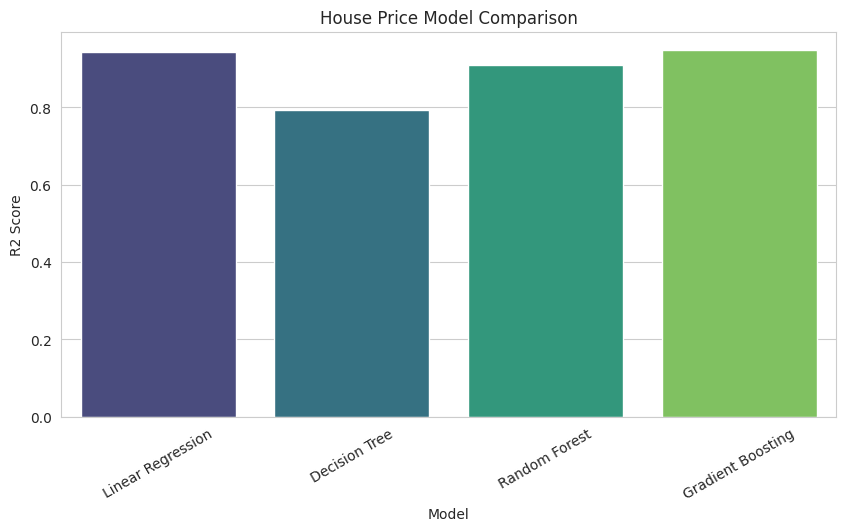

BEST MODEL: Gradient Boosting


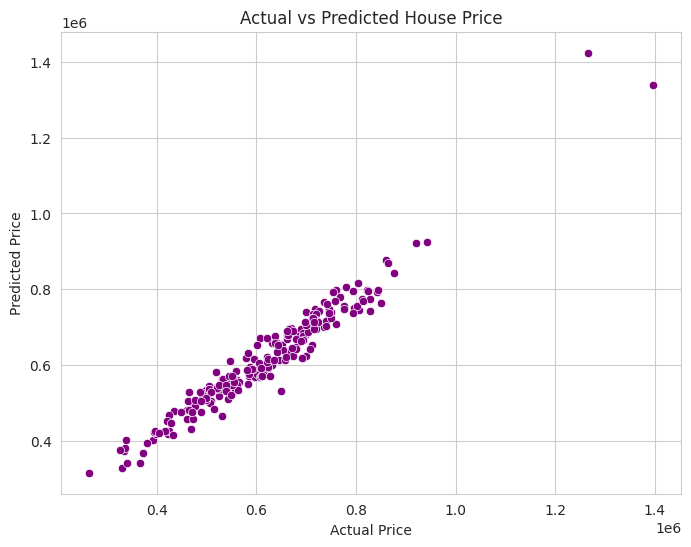

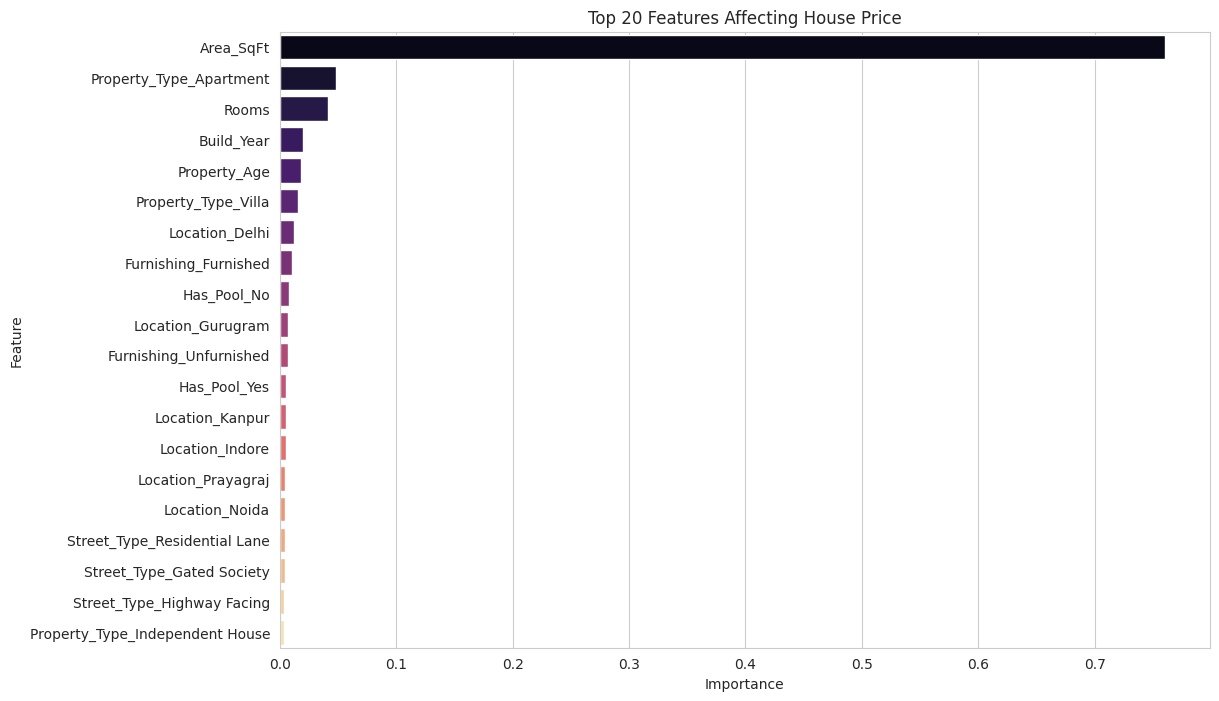


FINAL RESULT
Linear Regression : 0.9445
Decision Tree : 0.7933
Random Forest : 0.911
Gradient Boosting : 0.9485
BEST MODEL: Gradient Boosting
BEST R2 SCORE: 0.9485


In [11]:
from sklearn.model_selection import train_test_split


from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)


from sklearn.compose import ColumnTransformer


from sklearn.pipeline import Pipeline


from sklearn.impute import SimpleImputer


from sklearn.linear_model import LinearRegression


from sklearn.tree import DecisionTreeRegressor


from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)



from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)









# ============================================================
# TARGET
# ============================================================


target="Price"



X=df.drop(
    target,
    axis=1
)



y=df[target]









# ============================================================
# TRAIN TEST SPLIT BEFORE PREPROCESSING
# ============================================================


X_train,X_test,y_train,y_test=train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)











# ============================================================
# COLUMN SEPARATION
# ============================================================


numeric_cols=X.select_dtypes(
    include=np.number
).columns




categorical_cols=X.select_dtypes(
    include="object"
).columns










# ============================================================
# NUMERIC PIPELINE
# ============================================================


numeric_pipeline=Pipeline(

steps=[



(

"imputer",

SimpleImputer(
strategy="median"
)

),



(

"scaler",

StandardScaler()

)


]

)










# ============================================================
# CATEGORICAL PIPELINE
# ============================================================



categorical_pipeline=Pipeline(

steps=[



(

"imputer",

SimpleImputer(
strategy="most_frequent"
)

),




(

"encoder",

OneHotEncoder(
handle_unknown="ignore"
)

)


]

)











# ============================================================
# PREPROCESSOR
# ============================================================



preprocessor=ColumnTransformer(

transformers=[


(

"num",

numeric_pipeline,

numeric_cols

),



(

"cat",

categorical_pipeline,

categorical_cols

)


]

)









# ============================================================
# MODELS
# ============================================================


models={



"Linear Regression":

LinearRegression(),




"Decision Tree":

DecisionTreeRegressor(
random_state=42
),




"Random Forest":

RandomForestRegressor(

n_estimators=200,

random_state=42,

n_jobs=-1

),




"Gradient Boosting":

GradientBoostingRegressor(

random_state=42

)


}









results={}


trained={}










# ============================================================
# TRAINING MODELS
# ============================================================



for name,model in models.items():



    print("\n======================")
    print(name)
    print("======================")




    pipeline=Pipeline(

    steps=[



    (

    "preprocess",

    preprocessor

    ),




    (

    "model",

    model

    )


    ]

    )







    pipeline.fit(

        X_train,

        y_train

    )








    prediction=pipeline.predict(

        X_test

    )








    r2=r2_score(

        y_test,

        prediction

    )






    mae=mean_absolute_error(

        y_test,

        prediction

    )






    rmse=np.sqrt(

        mean_squared_error(

        y_test,

        prediction

        )

    )








    results[name]=r2


    trained[name]=pipeline







    print(
        "R2 Score:",
        round(r2,4)
    )


    print(
        "MAE:",
        round(mae,2)
    )


    print(
        "RMSE:",
        round(rmse,2)
    )










# ============================================================
# MODEL ACCURACY COMPARISON
# ============================================================


compare=pd.DataFrame({

"Model":list(results.keys()),

"R2 Score":list(results.values())

})





plt.figure(figsize=(10,5))


sns.barplot(

data=compare,

x="Model",

y="R2 Score",

hue="Model",

palette="viridis",

legend=False

)


plt.title(
"House Price Model Comparison"
)


plt.xticks(rotation=30)


plt.show()










# ============================================================
# BEST MODEL
# ============================================================



best_name=max(

results,

key=results.get

)




best_model=trained[
best_name
]





print(
"BEST MODEL:",
best_name
)










# ============================================================
# ACTUAL VS PREDICTED PRICE
# ============================================================


pred=best_model.predict(
    X_test
)





plt.figure(figsize=(8,6))



sns.scatterplot(

x=y_test,

y=pred,

color="purple"

)



plt.xlabel(
"Actual Price"
)



plt.ylabel(
"Predicted Price"
)



plt.title(
"Actual vs Predicted House Price"
)



plt.show()










# ============================================================
# FEATURE IMPORTANCE
# RANDOM FOREST
# ============================================================



rf=trained[

"Random Forest"

]





feature_names=(

list(numeric_cols)


+


list(

rf.named_steps["preprocess"]

.named_transformers_["cat"]

.named_steps["encoder"]

.get_feature_names_out(

categorical_cols

)

)

)








importance=pd.DataFrame({


"Feature":feature_names,


"Importance":

rf.named_steps["model"]

.feature_importances_


})








importance=importance.sort_values(

"Importance",

ascending=False

)








plt.figure(figsize=(12,8))



sns.barplot(

data=importance.head(20),

x="Importance",

y="Feature",

hue="Feature",

palette="magma",

legend=False

)



plt.title(
"Top 20 Features Affecting House Price"
)


plt.show()











# ============================================================
# FINAL RESULT
# ============================================================


print("\nFINAL RESULT")

print("=====================")



for model,score in results.items():

    print(

    model,

    ":",

    round(score,4)

    )




print("=====================")



print(
"BEST MODEL:",
best_name
)


print(
"BEST R2 SCORE:",
round(max(results.values()),4)
)